In [1]:
import os
import json
from pathlib import Path
import datetime as dt

import numpy as np
import pandas as pd 

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.transforms import v2
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader, Subset

# === cross valid ===
from sklearn.model_selection import GroupKFold

from custom_tools.tools import frame_video_split
from custom_tools.custom_logger import create_logger
from custom_tools.datasets import CADICADataset
from custom_tools.train_tools import befor_train_init, train_loop, compute_metrics
from custom_tools.architecture.ResNet_18_backbone import ResNet_18_Backbone

**LCA**

Сплит на **уровне видео** (одно видео пациента идет или в трейн или в тест).

Одна стадия обучения:
1) Заменяем последний слой - обучаем с большим LR (1e-3)

В принципе, после первого этапа обучения, почти получили метрики из [статьи](https://arxiv.org/pdf/2402.00570) для данного типа артерии (LCA), для данного размера пакета и данной архитектуры сети (ResNet-18)

---
Настраиваются все веса (backbone полностью разморожен)

Кросс-валидация

---

Из статьи:
* Accuracy: **0.712**
* Balanced Accuracy: **0.656**
* F1: **0.794**

Метрики после первого этапа:
* Accuracy: 
* Balanced Accuracy: 
* F1: 

Вторая часть не выполнялась

In [2]:
# ===================== PARAMETERS =====================
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# set seed
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PATH_SELECTED_VIDEO = Path("../../datasets/CADICA/selectedVideos")
frame_cadica = pd.read_csv("../data/cadica_dataset.csv")

TRAIN_SIZE_DATA = 0.8
BATCH_SIZE = 64
input_img_shape = (3,224,224)
split_level = "video_id"

class_weights = [1.7, 1]
weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

LR = 1e-3
MOMENTUM = 0.9
LAMBDA_LR = 1e-4

cv_n_split = 5
EPOCHS = 10
EARLY_STOPPING = 5
STEP_BATCH_LOG = 10

base_dir_for_model_save = "../models_checkpoints" # dir for models save

model_name = "resnet_18_backbone_cv" # model train name
prefix_train = "full_tuning_patient" # prefix train



# ============ comment for log ============
comment = f""" 
===== general parameters =====
SEED: {SEED}
DEVICE: {DEVICE}

PATH_SELECTED_VIDEO: {PATH_SELECTED_VIDEO}

TRAIN_SIZE_DATA: {TRAIN_SIZE_DATA}
BATCH_SIZE: {BATCH_SIZE}
input_img_shape: {input_img_shape}
split_level: {split_level}

===== train parameters =====
class_weights: {class_weights}
weights: {weights}

LR: {LR}
MOMENTUM: {MOMENTUM}
LAMBDA_LR: {LAMBDA_LR}

cv_n_split: {cv_n_split}
EPOCHS: {EPOCHS}
EARLY_STOPPING: {EARLY_STOPPING}
STEP_BATCH_LOG: {STEP_BATCH_LOG}

===== about model and save =====
base_dir_for_model_save: {base_dir_for_model_save}

model_name: {model_name}
prefix_train: {prefix_train}

===== comments =====
LCA
cross-validation
split patient level
SGDM optimizer
use augmentation
use ImageNet stats for (mean, std) normalization 
"""

## Load and split frame

In [3]:
# === разбиение на LCA и RCA === 
lca_cadica_frame = frame_cadica[frame_cadica['artery'] == 'LCA']

# === split LCA and RCA frames for train/test ===
frame_lca_train, frame_lca_test = frame_video_split(lca_cadica_frame, split_level, TRAIN_SIZE_DATA)

# === для преобразований ===
train_transform = v2.Compose([
    v2.RandomAffine(
        degrees=25,                          
        translate=(25/512, 25/512),          
        scale=(0.8, 1.7),                    
        interpolation=InterpolationMode.BILINEAR,
        fill=0                               
    ),
    v2.Resize((224, 224)),               
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True), # Преобразование типа, scale=True (масштабирование значений от 0 до 1)
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Нормализация от ImageNet
])

test_transform = v2.Compose([
    v2.Resize((224, 224)),               
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# === test datasets create ===
# LCA
test_lca_dataset = CADICADataset(frame_lca_test, "image_path", "label", transform=test_transform)

test_loader = DataLoader(
    test_lca_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1
)

In [5]:
time_now = dt.datetime.now().strftime("%Y-%m-%d_%H_%M_%S")
path2save = befor_train_init(
    base_dir_for_model_save,
    model_name,
    time_now,
    prefix_train
)
train_logger = create_logger(path2save, "train_log.log")
train_logger.info(comment)

2026-04-09 18:41:57,182 - INFO -  
===== general parameters =====
SEED: 42
DEVICE: cuda

PATH_SELECTED_VIDEO: ..\..\datasets\CADICA\selectedVideos

TRAIN_SIZE_DATA: 0.8
BATCH_SIZE: 64
input_img_shape: (3, 224, 224)
split_level: patient

===== train parameters =====
class_weights: [1.7, 1]
weights: tensor([1.7000, 1.0000], device='cuda:0')

LR: 0.001
MOMENTUM: 0.9
LAMBDA_LR: 0.0001

cv_n_split: 5
EPOCHS: 10
EARLY_STOPPING: 5
STEP_BATCH_LOG: 10

===== about model and save =====
base_dir_for_model_save: ../models_checkpoints

model_name: resnet_18_backbone_cv
prefix_train: full_tuning_patient

===== comments =====
LCA
cross-validation
split patient level
SGDM optimizer
use augmentation
use ImageNet stats for (mean, std) normalization 



In [6]:
# === cross validation loop ===
gkf = GroupKFold(n_splits=cv_n_split)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(frame_lca_train, groups=frame_lca_train[split_level])):

    train_logger.info(f"\n\n--------------------------- Training Fold {fold+1} ---------------------------")
    
    # ========== Создаем выборки для конкретного фолда ==========
    df_train = frame_lca_train.iloc[train_idx].reset_index(drop=True)
    df_val = frame_lca_train.iloc[val_idx].reset_index(drop=True)
    
    # ========== Инициализируем датасеты и лоадеры ==========
    train_ds = CADICADataset(df_train, "image_path", "label", transform=train_transform)
    valid_ds = CADICADataset(df_val, "image_path", "label", transform=test_transform)
    
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=1
    )
    val_loader = DataLoader(
        valid_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=1
    )

    # ========== model init ==========
    model_resnet = ResNet_18_Backbone(input_img_shape, out_classes=2, freeze_backbone=False).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.SGD(model_resnet.parameters(), lr=LR, weight_decay=LAMBDA_LR, momentum=MOMENTUM)
    
    total_params = sum(p.numel() for p in model_resnet.parameters())
    trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
    
    train_logger.info(f"Всего параметров: {total_params:,}")
    train_logger.info(f"Обучаемых:       {trainable_params:,}")

    # ========== create dir for save model ==========
    path2save_model_fold = f"{path2save}/fold{fold+1}"
    os.makedirs(path2save_model_fold, exist_ok=True)
    os.makedirs(f"{path2save_model_fold}/checkpoint", exist_ok=True)

    # ========== Запуск цикла обучения ==========
    train_history = train_loop(
        model_resnet, 
        loss_fn, 
        optimizer, 
        train_loader, 
        val_loader, 
        path_to_model_save=path2save_model_fold,
        step_batch_log = STEP_BATCH_LOG,
        early_stopping_epoch = EARLY_STOPPING,
        logger = train_logger,
        device = DEVICE, 
        epochs = EPOCHS,
        seed = SEED
    )

    # ========== Сохранение метрик хода обучения ==========
    path2save_model_fold
    with open(f"{path2save_model_fold}/train_history.json", "w", encoding="utf-8") as f:
        json.dump(train_history, f, ensure_ascii=False, indent=4)

    # ========== Логирование ==========



2026-04-09 18:41:58,802 - INFO - 

--------------------------- Training Fold 1 ---------------------------
2026-04-09 18:41:59,035 - INFO - Всего параметров: 11,177,538
2026-04-09 18:41:59,035 - INFO - Обучаемых:       11,177,538
train: 9it [00:08,  1.15it/s]2026-04-09 18:42:11,660 - INFO - epoch 1 | batch 10 | train_loss: 0.01074315
train: 19it [00:16,  1.14it/s]2026-04-09 18:42:20,414 - INFO - epoch 1 | batch 20 | train_loss: 0.01058424
train: 29it [00:25,  1.08it/s]2026-04-09 18:42:29,371 - INFO - epoch 1 | batch 30 | train_loss: 0.01014358
train: 34it [00:30,  1.11it/s]
valid: 9it [00:07,  1.16it/s]
Computing metrics: 100%|██████████| 9/9 [00:07<00:00,  1.25it/s]
2026-04-09 18:42:48,377 - INFO - ================= epoch end =================
2026-04-09 18:42:48,377 - INFO - epoch 1 | train_loss: 0.64196637 | valid_loss: 0.63786237 | valid balanc. acc.: 0.49136801
2026-04-09 18:42:48,377 - INFO - metrics:
{'accuracy': 0.7096774193548387, 'balanced_accuracy': 0.491368006993007, 'f1': 

## Print train metrics

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
path2save = "../models_checkpoints/resnet_18_backbone_cv/2026-04-09_17_42_55_full_tuning"

In [16]:
metrics_for_plots = dict()

for i in range(cv_n_split):
    fold = f"fold{i+1}"
    path2metrics_data = f"{path2save}/{fold}/train_history.json"
    with open(path2metrics_data, 'r') as f:
        metrics = json.load(f)
    metrics_for_plots[fold] = metrics

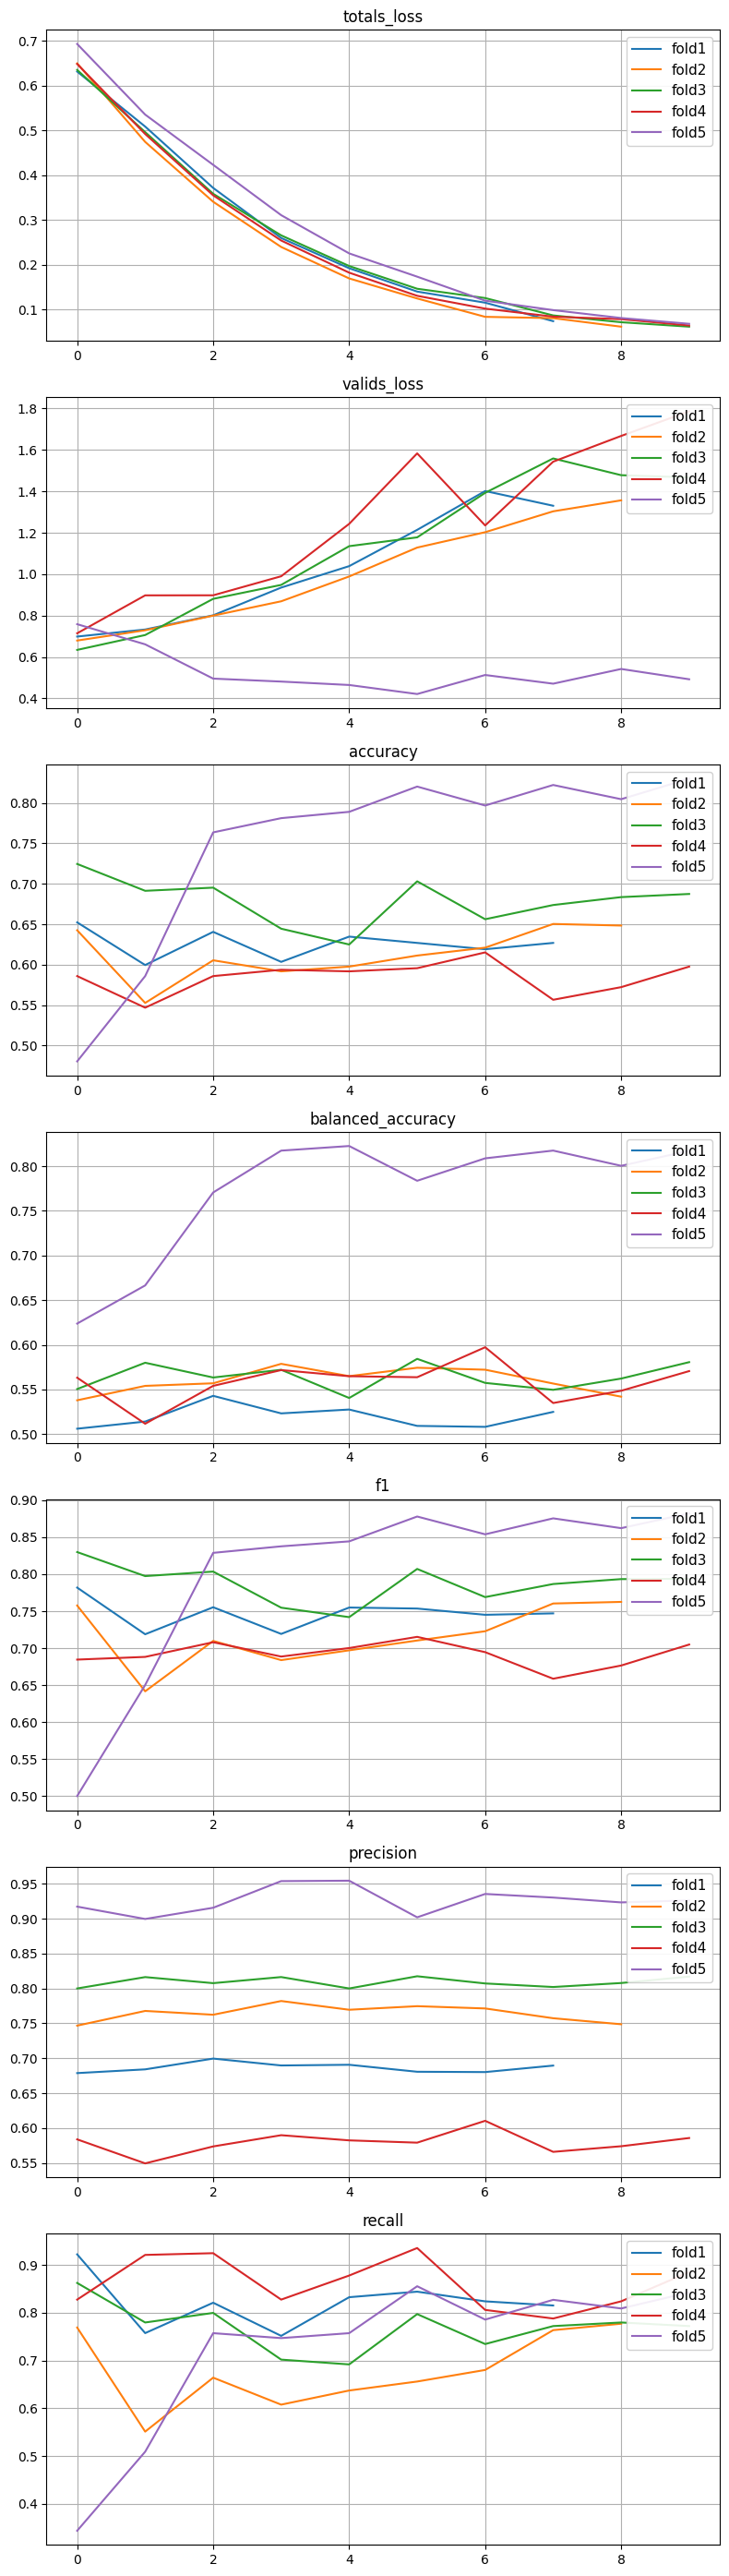

In [17]:
metrics_keys = ["totals_loss", "valids_loss", "accuracy", "balanced_accuracy", "f1", "precision", "recall"]
rows = len(metrics_keys)
cols = 1

fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 8, rows * 4))

for i in range(rows):    

    for fold in list(metrics_for_plots.keys()):
        
        ax[i].plot(metrics_for_plots[fold][metrics_keys[i]], label=fold)

    ax[i].legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax[i].set_title(metrics_keys[i])
    ax[i].grid(True)

plt.tight_layout() 
plt.show()

## Eval with all models

In [5]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score

In [8]:
# === model init ===
models_ensamble = dict()

for i in range(cv_n_split):
    fold = f"fold{i+1}"
    
    model = ResNet_18_Backbone(input_img_shape, out_classes=2, freeze_backbone=False)
    model.load_state_dict(torch.load(
        f"{path2save}/{fold}/checkpoint/best_model.pth"
    )['state_dict'])
    model.to(DEVICE)
    model.eval()
    models_ensamble[fold] = model

### Отдельная оценка каждой модели

In [9]:
metrics_model = dict()
with torch.no_grad():
    for key_model in list(models_ensamble.keys()):
        # === calculate all metrics any model ===
        metrics = compute_metrics(models_ensamble[key_model], test_loader, DEVICE)    
        metrics_model[key_model] = metrics

Computing metrics: 100%|██████████| 11/11 [00:09<00:00,  1.17it/s]


In [10]:
for key in metrics_model.keys():
    print(key, end=" | ")
    for metric_key in metrics_model[key].keys():
        print(f"{metric_key}: {metrics_model[key][metric_key]:.4f}", end=" | ")
    print()

fold1 | accuracy: 0.6302 | balanced_accuracy: 0.5309 | f1: 0.7497 | precision: 0.6801 | recall: 0.8352 | 
fold2 | accuracy: 0.5883 | balanced_accuracy: 0.5485 | f1: 0.6835 | precision: 0.6972 | recall: 0.6704 | 
fold3 | accuracy: 0.6213 | balanced_accuracy: 0.5220 | f1: 0.7431 | precision: 0.6753 | recall: 0.8262 | 
fold4 | accuracy: 0.6347 | balanced_accuracy: 0.5682 | f1: 0.7371 | precision: 0.7052 | recall: 0.7720 | 
fold5 | accuracy: 0.5823 | balanced_accuracy: 0.5462 | f1: 0.6760 | precision: 0.6962 | recall: 0.6569 | 


### Оценка ансамбля моделей

In [11]:
# === eval test ===
all_labels = []
all_preds = dict()

with torch.no_grad():
    for batch, (images, labels) in enumerate(test_loader):
        all_labels.extend(labels.cpu().numpy())
        for key_model in list(models_ensamble.keys()):
            outputs = models_ensamble[key_model](images.to(DEVICE))
            preds = torch.argmax(outputs, dim=1)          
            if key_model not in all_preds:
                all_preds[key_model] = []
            all_preds[key_model].extend(preds.cpu().numpy())

In [12]:
predict_tensor = torch.stack([torch.tensor(all_preds[key], dtype=torch.long) for key in all_preds.keys()])
predict = torch.mode(predict_tensor, dim=0).values.numpy()

In [13]:
# === Test metrics calculate ===
print(f"accuracy_score: {accuracy_score(all_labels, predict):.8f}") 
print(f"balanced_accuracy_score: {balanced_accuracy_score(all_labels, predict):.8f}") 
print(f"f1_score: {f1_score(all_labels, predict):.8f}") 
print(f"precision_score: {precision_score(all_labels, predict):.8f}") 
print(f"recall_score: {recall_score(all_labels, predict):.8f}")

accuracy_score: 0.60628743
balanced_accuracy_score: 0.53147228
f1_score: 0.71931697
precision_score: 0.68218623
recall_score: 0.76072235
